In [ ]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

SEED = 42
np.random.seed(SEED)

print('Python:', platform.python_version())
print('pandas:', pd.__version__)
print('scikit-learn:', sklearn.__version__)

Python: 3.12.13
pandas: 2.2.2
scikit-learn: 1.6.1


In [ ]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame.rename(columns={'MedHouseVal': 'Price'})

print(housing.DESCR[:600])
df.head()


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latit


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
target = 'Price'

print('Shape:', df.shape)
print('Target dtype:', df[target].dtype)

audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_n': df.isna().sum(),
    'missing_pct': 100 * df.isna().mean(),
    'unique_n': df.nunique(dropna=False)
}).sort_values('missing_pct', ascending=False)

display(audit)
print('Duplicate rows:', df.duplicated().sum())
print(df[target].describe())

Shape: (20640, 9)
Target dtype: float64


,dtype,missing_n,missing_pct,unique_n
MedInc,float64,0,0.0,12928
HouseAge,float64,0,0.0,52
AveRooms,float64,0,0.0,19392
AveBedrms,float64,0,0.0,14233
Population,float64,0,0.0,3888
AveOccup,float64,0,0.0,18841
Latitude,float64,0,0.0,862
Longitude,float64,0,0.0,844
Price,float64,0,0.0,3842


Duplicate rows: 0
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: Price, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(16512, 8) (4128, 8)
(16512,) (4128,)


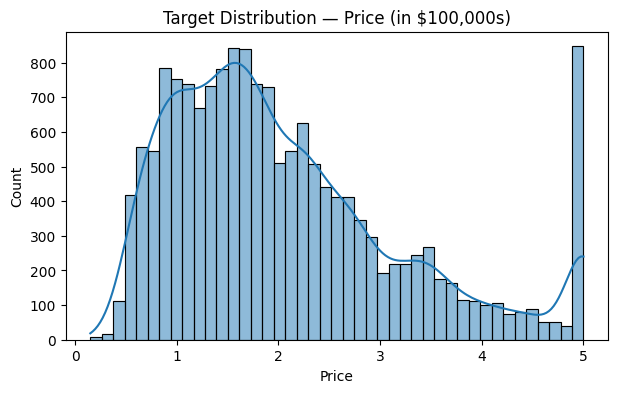

In [ ]:
train_df = X_train.copy()
train_df[target] = y_train

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(train_df[target], kde=True, ax=ax)
ax.set_title('Target Distribution — Price (in $100,000s)')
ax.set_xlabel('Price')
plt.show()


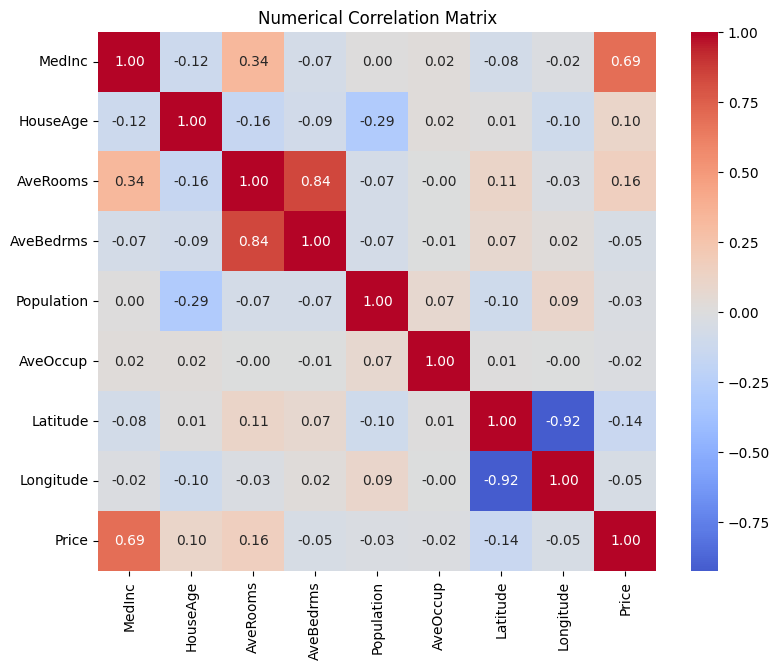

In [ ]:
num_df = train_df.select_dtypes(include=np.number)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(num_df.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('Numerical Correlation Matrix')
plt.show()

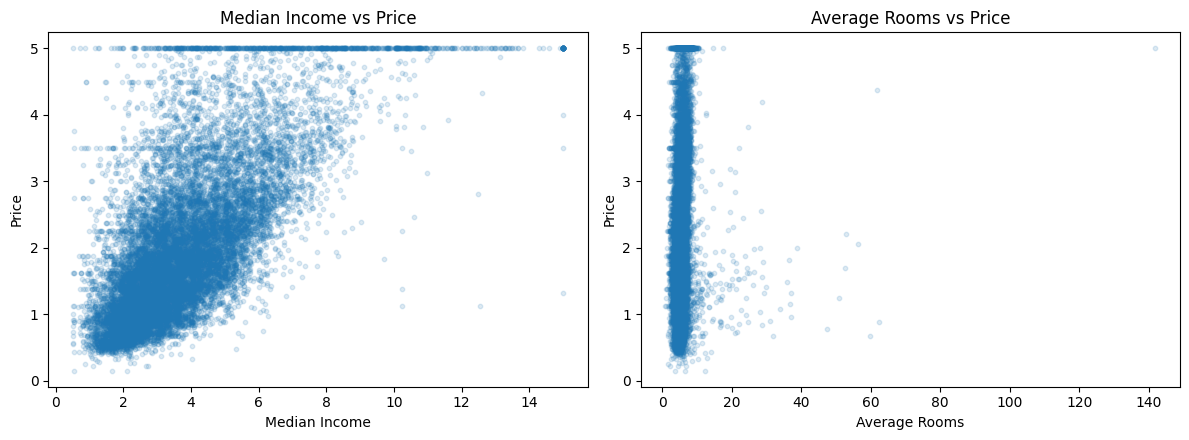

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(train_df['MedInc'], train_df[target], alpha=0.15, s=10)
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('Price')
axes[0].set_title('Median Income vs Price')

axes[1].scatter(train_df['AveRooms'], train_df[target], alpha=0.15, s=10)
axes[1].set_xlabel('Average Rooms')
axes[1].set_ylabel('Price')
axes[1].set_title('Average Rooms vs Price')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
], remainder='drop')

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Categorical features: []


In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

naive = DummyRegressor(strategy='mean')
naive.fit(X_train[numeric_features], y_train)
naive_pred = naive.predict(X_test[numeric_features])

naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))

print('Naive MAE:', naive_mae)
print('Naive RMSE:', naive_rmse)

Naive MAE: 0.9060685490007149
Naive RMSE: 1.1448563543099792


In [ ]:
from sklearn.linear_model import LinearRegression

simple_feature = 'MedInc'
simple_model = LinearRegression()
simple_model.fit(X_train[[simple_feature]], y_train)
simple_pred = simple_model.predict(X_test[[simple_feature]])

print('Intercept:', simple_model.intercept_)
print('Slope:', simple_model.coef_[0])

simple_mae = mean_absolute_error(y_test, simple_pred)
simple_rmse = np.sqrt(mean_squared_error(y_test, simple_pred))
simple_r2 = r2_score(y_test, simple_pred)
print(f'MAE: {simple_mae:.4f}  RMSE: {simple_rmse:.4f}  R2: {simple_r2:.4f}')


Intercept: 0.4445972916907879
Slope: 0.4193384939381271
MAE: 0.6299  RMSE: 0.8421  R2: 0.4589


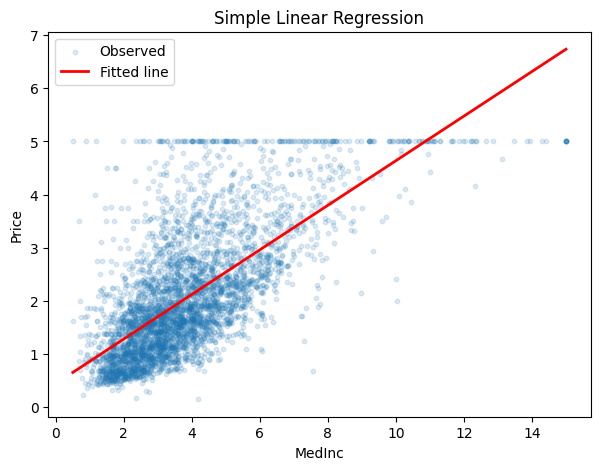

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_test[simple_feature], y_test, alpha=0.15, s=10, label='Observed')
order = np.argsort(X_test[simple_feature].to_numpy())
ax.plot(X_test[simple_feature].to_numpy()[order], simple_pred[order], linewidth=2, color='red', label='Fitted line')
ax.set_xlabel(simple_feature)
ax.set_ylabel(target)
ax.set_title('Simple Linear Regression')
ax.legend()
plt.show()

In [ ]:
linear_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])
linear_pipeline.fit(X_train, y_train)
linear_pred = linear_pipeline.predict(X_test)

lr_mae = mean_absolute_error(y_test, linear_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
lr_r2 = r2_score(y_test, linear_pred)
print(f'MAE: {lr_mae:.4f}  RMSE: {lr_rmse:.4f}  R2: {lr_r2:.4f}')

MAE: 0.5332  RMSE: 0.7456  R2: 0.5758


In [ ]:
def evaluate_regressor(name, fitted_model, X_eval, y_eval):
    pred = fitted_model.predict(X_eval)
    mae = mean_absolute_error(y_eval, pred)
    mse = mean_squared_error(y_eval, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_eval, pred)
    Xt = fitted_model.named_steps['preprocess'].transform(X_eval)
    n, p = Xt.shape
    adj_r2 = np.nan if n <= p + 1 else 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'Adjusted_R2': adj_r2}, pred

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

model_specs = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=20000),
    'Elastic Net': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000),
    'Decision Tree': DecisionTreeRegressor(max_depth=6, random_state=SEED),
    'Random Forest': RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=SEED)
}

fitted_models = {}
results = []
predictions = {}

for name, estimator in model_specs.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', estimator)])
    pipe.fit(X_train, y_train)
    row, pred = evaluate_regressor(name, pipe, X_test, y_test)
    results.append(row)
    fitted_models[name] = pipe
    predictions[name] = pred

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

,Model,MAE,MSE,RMSE,R2,Adjusted_R2
5,Random Forest,0.326235,0.253812,0.503798,0.806310,0.805934
6,Gradient Boosting,0.371650,0.293999,0.542217,0.775643,0.775208
4,Decision Tree,0.500804,0.497284,0.705184,0.620513,0.619775
2,Lasso,0.533145,0.554491,0.744642,0.576856,0.576034
3,Elastic Net,0.533123,0.554902,0.744917,0.576543,0.575721
1,Ridge,0.533193,0.555855,0.745557,0.575816,0.574992
0,Linear Regression,0.533200,0.555892,0.745581,0.575788,0.574964


In [ ]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

cv_rows = []
for name, estimator in model_specs.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', estimator)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'CV_MAE_mean': -scores['test_mae'].mean(),
        'CV_RMSE_mean': -scores['test_rmse'].mean(),
        'CV_RMSE_std': scores['test_rmse'].std(),
        'CV_R2_mean': scores['test_r2'].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values('CV_RMSE_mean')
cv_results

,Model,CV_MAE_mean,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean
5,Random Forest,0.333120,0.509620,0.011518,0.805647
6,Gradient Boosting,0.369779,0.532138,0.011575,0.788084
4,Decision Tree,0.497764,0.692767,0.013169,0.640906
2,Lasso,0.529115,0.720499,0.013853,0.611468
3,Elastic Net,0.529060,0.720507,0.013875,0.611460
1,Ridge,0.529056,0.720509,0.013895,0.611457
0,Linear Regression,0.529061,0.720510,0.013895,0.611457


In [ ]:
from sklearn.model_selection import GridSearchCV

ridge_pipe = Pipeline([('preprocess', preprocess), ('model', Ridge())])
ridge_grid = {'model__alpha': np.logspace(-3, 3, 13)}

search = GridSearchCV(
    ridge_pipe, param_grid=ridge_grid, scoring='neg_root_mean_squared_error',
    cv=cv, n_jobs=-1, return_train_score=True
)
search.fit(X_train, y_train)

print('Best parameters:', search.best_params_)
print('Best CV RMSE:', -search.best_score_)
best_ridge = search.best_estimator_

Best parameters: {'model__alpha': np.float64(3.1622776601683795)}
Best CV RMSE: 0.7205088107791665


In [ ]:
def split_metrics(model, X_train, y_train, X_test, y_test):
    rows = []
    for split_name, Xs, ys in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
        pred = model.predict(Xs)
        rows.append({
            'Split': split_name,
            'MAE': mean_absolute_error(ys, pred),
            'RMSE': np.sqrt(mean_squared_error(ys, pred)),
            'R2': r2_score(ys, pred)
        })
    return pd.DataFrame(rows)

for name in ['Linear Regression', 'Decision Tree', 'Random Forest']:
    print(name)
    display(split_metrics(fitted_models[name], X_train, y_train, X_test, y_test))


Linear Regression


,Split,MAE,RMSE,R2
0,Train,0.528628,0.719676,0.612551
1,Test,0.533200,0.745581,0.575788


Decision Tree


,Split,MAE,RMSE,R2
0,Train,0.473438,0.655831,0.678245
1,Test,0.500804,0.705184,0.620513


Random Forest


,Split,MAE,RMSE,R2
0,Train,0.143632,0.233830,0.959098
1,Test,0.326235,0.503798,0.806310


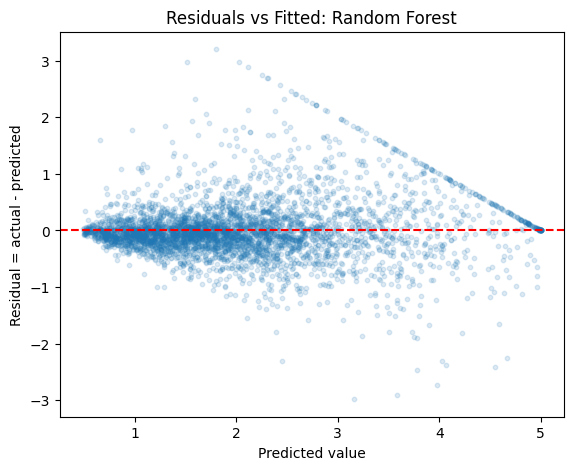

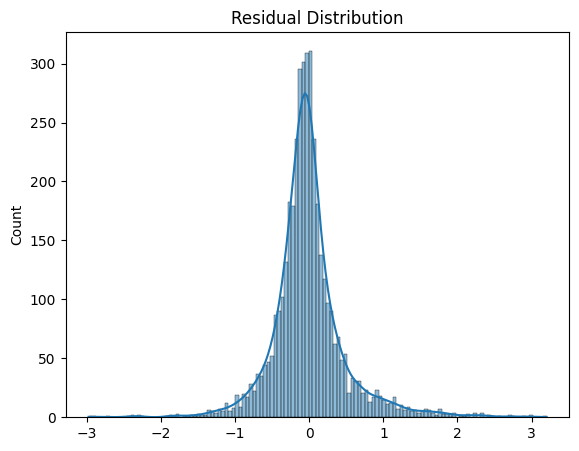

In [ ]:
selected_name = results_df.iloc[0]['Model']
y_pred = predictions[selected_name]
residuals = y_test.to_numpy() - y_pred

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(y_pred, residuals, alpha=0.15, s=10)
ax.axhline(0, linestyle='--', color='red')
ax.set_xlabel('Predicted value')
ax.set_ylabel('Residual = actual - predicted')
ax.set_title(f'Residuals vs Fitted: {selected_name}')
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.histplot(residuals, kde=True, ax=ax)
ax.set_title('Residual Distribution')
plt.show()


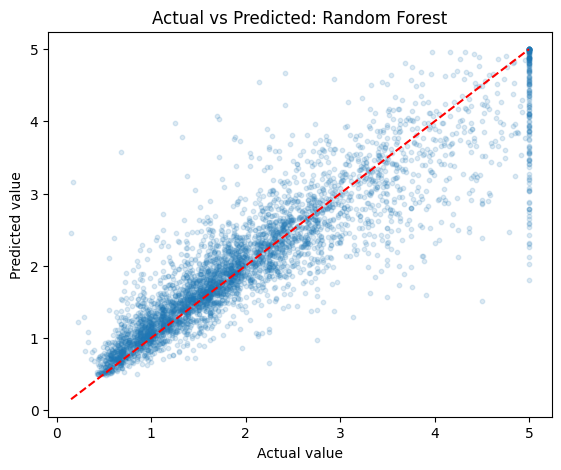

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(y_test, y_pred, alpha=0.15, s=10)
lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax.plot([lo, hi], [lo, hi], linestyle='--', color='red')
ax.set_xlabel('Actual value')
ax.set_ylabel('Predicted value')
ax.set_title(f'Actual vs Predicted: {selected_name}')
plt.show()

In [ ]:
linear_fitted = fitted_models['Linear Regression']
feature_names = linear_fitted.named_steps['preprocess'].get_feature_names_out()
coefficients = linear_fitted.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'AbsCoefficient': np.abs(coefficients)
}).sort_values('AbsCoefficient', ascending=False)

coef_df


,Feature,Coefficient,AbsCoefficient
6,num__Latitude,-0.896929,0.896929
7,num__Longitude,-0.869842,0.869842
0,num__MedInc,0.854383,0.854383
3,num__AveBedrms,0.339259,0.339259
2,num__AveRooms,-0.294410,0.294410
1,num__HouseAge,0.122546,0.122546
5,num__AveOccup,-0.040829,0.040829
4,num__Population,-0.002308,0.002308


In [ ]:
import json
import joblib

final_model = best_ridge  # replace with your justified final model choice

joblib.dump(final_model, 'house_price_pipeline.joblib')
results_df.to_csv('test_model_comparison.csv', index=False)
cv_results.to_csv('cross_validation_results.csv', index=False)

run_metadata = {
    'random_seed': SEED,
    'target': target,
    'train_rows': len(X_train),
    'test_rows': len(X_test),
    'selected_model': 'Tuned Ridge Regression'
}
with open('run_metadata.json', 'w') as f:
    json.dump(run_metadata, f, indent=2)

print('Artifacts saved.')

Artifacts saved.
